<a href="https://colab.research.google.com/github/angulorojasmariaclaudia-coder/TRABAJO-FINAL-AP-/blob/main/TRABAJO_FINAL_AP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **3. Metodología**

En este apartado se presenta la metodología seguida para aplicar la Semi-Supervised GAN a un caso de estudio concreto. Tras haber introducido los fundamentos teóricos, se define ahora cómo se va a trasladar este enfoque a un problema práctico de clasificación de imágenes utilizando Fashion-MNIST.

Primero se describe el conjunto de datos empleado y el preprocesamiento aplicado a las imágenes. Después se explica cómo se construye el escenario semi-supervisado, limitando el número de etiquetas disponibles durante el entrenamiento. A continuación, se introduce un modelo baseline basado en una CNN supervisada, que servirá como referencia para comparar los resultados.

Posteriormente, se describe la arquitectura de la Semi-Supervised GAN utilizada en el caso de estudio, incluyendo el papel del generador y del discriminador semi-supervisado. Finalmente, se detallan el procedimiento de entrenamiento, las funciones de pérdida y los criterios utilizados para evaluar el rendimiento del modelo.

### **3.1. Dataset utilizado**

Para este trabajo se utiliza Fashion-MNIST, un conjunto de imágenes en escala de grises pertenecientes a 10 categorías de prendas y accesorios. Todas las imágenes tienen el mismo tamaño, 28 × 28 píxeles, lo que permite trabajar con arquitecturas convolucionales sencillas y centrar el análisis en el funcionamiento del modelo semi-supervisado.

Las clases del dataset son:

* 0: T-shirt/top
* 1: Trouser
* 2: Pullover
* 3: Dress
* 4: Coat
* 5: Sandal
* 6: Shirt
* 7: Sneaker
* 8: Bag
* 9: Ankle boot

El problema se plantea como una tarea de clasificación multiclase, donde el objetivo es asignar correctamente cada imagen a una de las 10 clases disponibles.

### **3.2. Preprocesamiento de los datos**

Antes de entrenar los modelos, las imágenes se transforman para adaptarlas al formato requerido por las redes neuronales convolucionales.

En primer lugar, los valores de los píxeles se convierten a tipo float32. Después, se normalizan al intervalo [-1, 1]. Esta normalización se utiliza porque el generador de la GAN emplea una función de activación tanh en su capa final, cuya salida también se encuentra en ese mismo intervalo.

Además, se añade una dimensión de canal a las imágenes. Originalmente, cada imagen tiene forma: 28 × 28, donde, después del preprocesamiento, cada imagen queda representada como: 28 × 28 × 1. El último valor indica que se trata de imágenes en escala de grises.

Con esto, las imágenes quedan preparadas para ser utilizadas tanto por el clasificador como por el generador y el discriminador de la SGAN.

### **3.3. Creación del escenario semi-supervisado**

Aunque Fashion-MNIST contiene etiquetas para todas las imágenes, en este trabajo se simula un escenario semi-supervisado. Para ello, durante el entrenamiento solo se utiliza una pequeña parte de las etiquetas disponibles.

Por ejemplo, si se seleccionan 10 imágenes etiquetadas por clase, se obtiene un subconjunto de 100 imágenes etiquetadas en total. Estas imágenes forman `X_labeled` e `y_labeled`.

El resto de imágenes del conjunto de entrenamiento no se descarta. Se utilizan como imágenes reales no etiquetadas: el modelo puede verlas, pero no recibe información sobre su clase concreta. Es decir, no se le indica si una imagen corresponde a una camiseta, un zapato, un bolso u otra categoría; únicamente se utiliza para que el discriminador aprenda cómo son las imágenes reales del conjunto de datos.

La separación conceptual es la siguiente:

| Conjunto           | Qué contiene                                  | Para qué se usa                                       |
| ------------------ | --------------------------------------------- | ----------------------------------------------------- |
| `X_labeled`        | Imágenes reales con etiqueta                  | Entrenar la parte clasificadora del discriminador     |
| `y_labeled`        | Etiquetas de `X_labeled`                      | Indicar la clase correcta de esas imágenes            |
| `X_train`          | Imágenes reales del conjunto de entrenamiento | Enseñar al discriminador cómo son las imágenes reales |
| Imágenes generadas | Imágenes creadas por el generador             | Enseñar al discriminador a distinguir imágenes falsas |
| `X_test`, `y_test` | Imágenes y etiquetas de test                  | Evaluar el rendimiento final                          |

En otras palabras, el discriminador aprende de dos maneras. Por un lado, con las pocas imágenes etiquetadas aprende a clasificar prendas. Por otro lado, con las imágenes reales no etiquetadas aprende la estructura general de los datos, lo que puede ayudarle a construir mejores representaciones internas para la clasificación.

### **3.4. Modelo baseline: CNN supervisada**

Antes de implementar la SGAN, se entrena una red neuronal convolucional convencional que actúa como modelo de referencia. Este modelo permite establecer una comparación inicial y comprobar qué rendimiento se obtiene utilizando únicamente las imágenes etiquetadas disponibles.

La CNN se entrena solo con el subconjunto `X_labeled` e `y_labeled`, por lo que no utiliza el resto de imágenes del conjunto de entrenamiento. De esta forma, representa un enfoque puramente supervisado en un escenario con pocas etiquetas.

Su arquitectura sigue una estructura típica de clasificación de imágenes: primero se aplican capas convolucionales para extraer características visuales, después se reduce la dimensión espacial mediante capas de pooling y, finalmente, se utilizan capas densas para obtener la predicción final.

La salida del modelo es una distribución de probabilidad sobre las 10 clases de Fashion-MNIST. La clase con mayor probabilidad se toma como predicción del modelo.

Este baseline sirve para valorar posteriormente si la SGAN consigue mejorar el rendimiento al aprovechar, además de las pocas imágenes etiquetadas, el resto de imágenes reales disponibles durante el entrenamiento.

### **3.5. Modelo principal: Semi-Supervised GAN**

El modelo principal del trabajo es una Semi-Supervised GAN, una adaptación de las GANs al aprendizaje semi-supervisado. Esta arquitectura está formada por dos redes: el generador y el discriminador.

El generador recibe como entrada un vector de ruido aleatorio y lo transforma progresivamente en una imagen artificial con el mismo formato que las imágenes reales del dataset. Al inicio del entrenamiento, las imágenes generadas no tienen una estructura clara, pero a medida que avanza el proceso el generador intenta producir imágenes cada vez más parecidas a las reales.

El discriminador recibe imágenes y cumple dos funciones. Por un lado, aprende a clasificar las imágenes reales etiquetadas en una de las 10 clases de Fashion-MNIST. Por otro lado, aprende a distinguir entre imágenes reales del conjunto de entrenamiento e imágenes artificiales creadas por el generador.

De esta forma, el discriminador no solo participa en la detección de imágenes generadas, sino que también actúa como clasificador. Al finalizar el entrenamiento, la parte supervisada del discriminador se utiliza como modelo final para predecir la clase de nuevas imágenes.

#### **3.5.1. Generador**

El generador es la parte de la SGAN encargada de producir imágenes artificiales. Para ello, recibe como entrada un vector de ruido aleatorio de dimensión fija. En este trabajo se utiliza una dimensión latente de 100 valores, definida en el código mediante la variable latent_dim = 100.

Este vector inicial no contiene información visual interpretable por sí mismo. Es simplemente una representación numérica aleatoria que el generador transforma progresivamente hasta obtener una imagen con el mismo formato que las imágenes reales del conjunto de datos, es decir, 28 × 28 × 1.

La arquitectura del generador comienza con una capa densa que proyecta el vector de entrada a una representación de mayor tamaño. Posteriormente, esta representación se reorganiza en una estructura espacial pequeña y se procesa mediante capas convolucionales transpuestas, que aumentan gradualmente la resolución hasta obtener una imagen final en escala de grises.


#### **3.5.2. Discriminador semi-supervisado**

El discriminador es el componente central de la SGAN para la tarea de clasificación. A diferencia de un discriminador convencional, que solo distingue entre imágenes reales y generadas, en este trabajo el discriminador se adapta para cumplir dos funciones complementarias.

En primer lugar, el discriminador actúa como clasificador supervisado. Para ello, utiliza las imágenes del subconjunto etiquetado, `X_labeled`, junto con sus etiquetas correspondientes, `y_labeled`. Con esta información aprende a asignar cada imagen a una de las 10 clases de Fashion-MNIST.

En segundo lugar, el discriminador aprende a distinguir entre imágenes reales e imágenes artificiales. Para esta parte del entrenamiento se utilizan, por un lado, imágenes reales procedentes del conjunto de entrenamiento y, por otro, imágenes creadas por el generador. En este caso, no se utiliza la etiqueta concreta de la prenda, sino únicamente la información de si la imagen procede del conjunto real o ha sido generada artificialmente.

Por tanto, el discriminador combina una tarea de clasificación con una tarea de detección real/fake. Esta doble función permite que el modelo aproveche las pocas imágenes etiquetadas disponibles y, al mismo tiempo, utilice el resto de imágenes reales para aprender mejor la estructura general de los datos.

Al finalizar el entrenamiento, la parte supervisada del discriminador se utiliza como clasificador final. Es decir, el modelo recibe una imagen y devuelve la probabilidad de pertenencia a cada una de las 10 clases del problema.

### **3.6. Entrenamiento de la SGAN**

El entrenamiento de la SGAN se realiza de forma alternada, ya que intervienen dos redes con objetivos diferentes: el generador y el discriminador. En cada iteración se actualizan distintas partes del modelo para que ambas redes vayan mejorando progresivamente.

En primer lugar, se entrena la parte supervisada del discriminador utilizando un pequeño lote de imágenes etiquetadas procedente de `X_labeled` e `y_labeled`. En esta fase, el discriminador aprende a asociar cada imagen con su clase correspondiente dentro de las 10 categorías de Fashion-MNIST. Esta es la parte del entrenamiento que permite utilizar posteriormente el discriminador como clasificador.

A continuación, se entrena la parte no supervisada del discriminador con imágenes reales del conjunto de entrenamiento. En este caso se utilizan imágenes de `X_train`, pero no se emplean sus etiquetas de clase. Es decir, el modelo no recibe información sobre si una imagen concreta corresponde a una camiseta, un zapato o un bolso; únicamente se le indica que se trata de una imagen real. Esta fase permite que el discriminador observe muchas más imágenes que las incluidas en el subconjunto etiquetado y aprenda características generales del conjunto de datos.

Después, el generador produce un lote de imágenes artificiales a partir de vectores de ruido aleatorio. Estas imágenes se utilizan para entrenar al discriminador en la tarea de reconocer ejemplos generados. De este modo, el discriminador aprende a diferenciar entre imágenes reales del conjunto de entrenamiento e imágenes creadas artificialmente por el generador.

Por último, se actualiza el generador. En esta fase, el discriminador se mantiene fijo temporalmente y el generador intenta producir imágenes que sean clasificadas como reales por el discriminador. Si las imágenes generadas son fácilmente detectadas como falsas, el generador recibe una penalización y ajusta sus pesos para mejorar en las siguientes iteraciones.


### **3.7. Funciones de pérdida**

Durante el entrenamiento se utilizan dos funciones de pérdida, ya que el modelo resuelve dos tareas distintas: clasificación de prendas y distinción entre imágenes reales e imágenes generadas.

Para la tarea de clasificación se utiliza Sparse Categorical Crossentropy. Esta función de pérdida se aplica a la salida supervisada del discriminador y mide la diferencia entre la clase real de una imagen etiquetada y la distribución de probabilidades predicha por el modelo. Es adecuada en este caso porque las etiquetas se representan como valores enteros entre 0 y 9.

Para la tarea de distinguir entre imágenes reales e imágenes generadas se utiliza Binary Crossentropy. Esta función se aplica a la salida real/fake del discriminador y también al modelo combinado que entrena el generador. En este caso, el problema es binario: una imagen puede ser real o generada.

Así, cada función de pérdida se corresponde con una parte concreta del entrenamiento. La pérdida de clasificación permite que el discriminador aprenda las clases de Fashion-MNIST, mientras que la pérdida binaria permite entrenar la interacción entre generador y discriminador.

### **3.8. Evaluación del modelo**

Una vez finalizado el entrenamiento, se evalúa el rendimiento del modelo sobre el conjunto de test. Para ello se utiliza la salida supervisada del discriminador, que actúa como clasificador final de las imágenes.

El resultado obtenido por la SGAN se compara con el de la CNN supervisada utilizada como baseline. Ambos modelos se entrenan con el mismo subconjunto reducido de imágenes etiquetadas, por lo que la comparación permite analizar si el uso adicional de imágenes reales no etiquetadas y de imágenes generadas aporta alguna mejora al proceso de aprendizaje.

La métrica principal utilizada es la accuracy, que mide la proporción de imágenes clasificadas correctamente. Además, se incluye una matriz de confusión para estudiar qué clases se confunden con mayor frecuencia, un informe de clasificación para observar el rendimiento por clase y un análisis visual de errores para revisar ejemplos concretos de predicciones incorrectas.

También se analizan las curvas de entrenamiento y las imágenes generadas por el modelo. Las curvas permiten observar la evolución de las pérdidas durante el entrenamiento, mientras que las imágenes generadas sirven para comprobar visualmente si el generador ha aprendido a producir ejemplos similares a los datos reales.

## **4. Implementación**

En este apartado se presenta la implementación práctica del caso de estudio descrito en la metodología. El código se ha desarrollado en Python utilizando TensorFlow y Keras, ya que estas librerías permiten construir de forma modular tanto redes convolucionales como modelos generativos.

La implementación sigue el mismo orden definido previamente: primero se cargan y preparan los datos, después se crea el escenario semi-supervisado, se entrena un modelo baseline y, finalmente, se implementan los componentes de la Semi-Supervised GAN.

### **4.1. Configuración inicial**

En primer lugar, se importan las librerías necesarias para la carga de datos, construcción de modelos, entrenamiento, visualización y evaluación. También se fija una semilla aleatoria para favorecer la reproducibilidad de los resultados.

In [7]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Dense, Conv2D, Conv2DTranspose, Flatten, Dropout,
    Reshape, LeakyReLU, BatchNormalization, MaxPooling2D, Lambda
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [8]:
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU disponible: []


### **4.2. Preparación de los datos**

#### **4.2.1. Carga del dataset**

En esta celda se carga Fashion-MNIST y se separan los datos en conjunto de entrenamiento y conjunto de test. Las variables `X_train` y `X_test` contienen las imágenes, mientras que `y_train` y `y_test` contienen sus etiquetas.

También se define una lista con los nombres de las clases, para facilitar la interpretación de los resultados y las visualizaciones.

In [9]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [10]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


También se define una lista con los nombres de las clases, para facilitar la interpretación de los resultados y las visualizaciones.

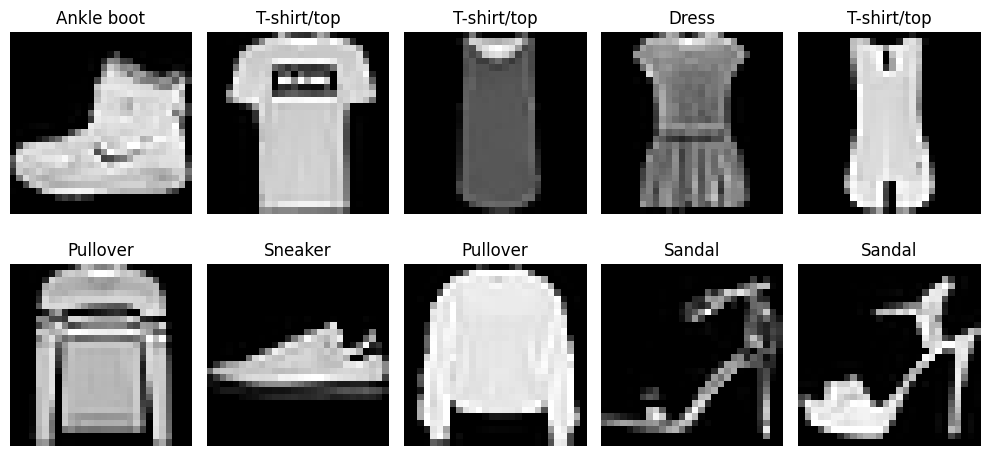

In [11]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

#### **4.2.2. Preprocesamiento de los datos**

Las imágenes se convierten a tipo float32 y se normalizan al intervalo [-1, 1]. Este paso es necesario porque el generador utiliza una activación tanh en su última capa, cuya salida se encuentra en ese mismo rango.

Además, se añade una dimensión de canal para que las imágenes tengan el formato esperado por las capas convolucionales.

In [12]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

X_train = (X_train - 127.5) / 127.5
X_test = (X_test - 127.5) / 127.5

X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Rango X_train:", X_train.min(), X_train.max())

X_train: (60000, 28, 28, 1)
X_test: (10000, 28, 28, 1)
Rango X_train: -1.0 1.0


#### **4.2.3. Creación del subconjunto etiquetado**

Para simular el escenario semi-supervisado, se selecciona un número reducido de imágenes etiquetadas por clase. La función siguiente recibe el conjunto de entrenamiento y devuelve un subconjunto equilibrado, con el mismo número de ejemplos por cada una de las 10 clases.

In [13]:
def seleccionar_muestras_etiquetadas(X, y, n_por_clase=10):
    X_labeled = []
    y_labeled = []

    for clase in range(10):
        indices = np.where(y == clase)[0]
        seleccionados = np.random.choice(indices, n_por_clase, replace=False)

        X_labeled.append(X[seleccionados])
        y_labeled.append(y[seleccionados])

    X_labeled = np.vstack(X_labeled)
    y_labeled = np.hstack(y_labeled)

    return X_labeled, y_labeled

En este experimento se seleccionan inicialmente 10 imágenes por clase, lo que produce un total de 100 imágenes etiquetadas.

In [14]:
N_POR_CLASE = 10

X_labeled, y_labeled = seleccionar_muestras_etiquetadas(
    X_train,
    y_train,
    n_por_clase=N_POR_CLASE
)

print("Imágenes etiquetadas:", X_labeled.shape)
print("Etiquetas:", y_labeled.shape)

Imágenes etiquetadas: (100, 28, 28, 1)
Etiquetas: (100,)


Se comprueba que la selección mantiene el mismo número de imágenes etiquetadas por clase.

In [15]:
unique, counts = np.unique(y_labeled, return_counts=True)

pd.DataFrame({
    "Clase": [class_names[i] for i in unique],
    "Número de imágenes etiquetadas": counts
})

,Clase,Número de imágenes etiquetadas
0,T-shirt/top,10
1,Trouser,10
2,Pullover,10
3,Dress,10
4,Coat,10
5,Sandal,10
6,Shirt,10
7,Sneaker,10
8,Bag,10
9,Ankle boot,10


### **4.3. Implementación del modelo baseline**

Antes de entrenar la SGAN, se implementa una CNN supervisada que servirá como modelo de referencia. Este modelo se entrena únicamente con el subconjunto etiquetado `X_labeled` e `y_labeled`.

In [16]:
def crear_clasificador_baseline(input_shape=(28, 28, 1), n_classes=10):
    model = Sequential(name="baseline_cnn")

    model.add(Conv2D(32, (3, 3), activation="relu", input_shape=input_shape))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (3, 3), activation="relu"))
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.4))
    model.add(Dense(n_classes, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [17]:
baseline = crear_clasificador_baseline()
baseline.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

El modelo se entrena con las imágenes etiquetadas seleccionadas previamente y se valida sobre el conjunto de test.

In [18]:
history_baseline = baseline.fit(
    X_labeled,
    y_labeled,
    epochs=40,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2000 - loss: 2.2605 - val_accuracy: 0.2559 - val_loss: 2.0912
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 983ms/step - accuracy: 0.3200 - loss: 2.0308 - val_accuracy: 0.4480 - val_loss: 1.8820
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 916ms/step - accuracy: 0.4500 - loss: 1.7834 - val_accuracy: 0.5508 - val_loss: 1.6160
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.6000 - loss: 1.4967 - val_accuracy: 0.5928 - val_loss: 1.3697
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5700 - loss: 1.3399 - val_accuracy: 0.6364 - val_loss: 1.1664
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 933ms/step - accuracy: 0.6700 - loss: 1.0931 - val_accuracy: 0.6362 - val_loss: 1.0610
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6300 - loss: 0.9393 - val_accuracy: 0.6526 - val_loss: 0.9733
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.7200 - loss: 0.8211 - val_accuracy: 0.6646 - val_loss: 0.9097
Epoch 9

Finalmente, se obtiene su rendimiento sobre el conjunto de test.

In [19]:
loss_baseline, acc_baseline = baseline.evaluate(X_test, y_test, verbose=0)

print("Accuracy baseline CNN:", acc_baseline)

Accuracy baseline CNN: 0.6887999773025513


### **4.4. Implementación del discriminador semi-supervisado**

#### **4.4.1. Discriminador semi-supervisado**

El discriminador se implementa con una arquitectura convolucional compartida. A partir de esta base común se definen dos modelos: uno supervisado, que clasifica imágenes en 10 clases, y otro no supervisado, que estima si una imagen es real o generada.

La función `custom_activation` permite obtener la salida real/fake a partir de los logits de clasificación.

In [20]:
def custom_activation(x):
    ex = K.exp(x)
    sum_ex = K.sum(ex, axis=-1, keepdims=True)
    return sum_ex / (sum_ex + 1.0)

In [21]:
def crear_discriminador(input_shape=(28, 28, 1), n_classes=10):
    entrada = Input(shape=input_shape, name="input_image")

    x = Conv2D(64, (3, 3), strides=(2, 2), padding="same")(entrada)
    x = LeakyReLU(0.2)(x)
    x = Dropout(0.4)(x)

    x = Conv2D(128, (3, 3), strides=(2, 2), padding="same")(x)
    x = LeakyReLU(0.2)(x)
    x = Dropout(0.4)(x)

    x = Conv2D(256, (3, 3), strides=(2, 2), padding="same")(x)
    x = LeakyReLU(0.2)(x)
    x = Dropout(0.4)(x)

    x = Flatten()(x)
    x = Dense(128)(x)
    x = LeakyReLU(0.2)(x)

    logits = Dense(n_classes, name="class_logits")(x)

    salida_supervisada = tf.keras.layers.Activation(
        "softmax",
        name="supervised_output"
    )(logits)

    salida_no_supervisada = Lambda(
        custom_activation,
        name="unsupervised_output"
    )(logits)

    modelo_supervisado = Model(
        entrada,
        salida_supervisada,
        name="supervised_discriminator"
    )

    modelo_no_supervisado = Model(
        entrada,
        salida_no_supervisada,
        name="unsupervised_discriminator"
    )

    modelo_supervisado.compile(
        optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    modelo_no_supervisado.compile(
        optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return modelo_supervisado, modelo_no_supervisado

In [22]:
supervised_discriminator, unsupervised_discriminator = crear_discriminador()

supervised_discriminator.summary()

Model: "supervised_discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_logits (Dense)            │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ supervised_output (Activation)  │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 895,370 (3.42 MB)

 Trainable params: 895,370 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

#### **4.4.2. Generador**

El generador recibe un vector de ruido de dimensión 100 y lo transforma en una imagen artificial con formato 28 × 28 × 1.

In [23]:
def crear_generador(latent_dim=100):
    model = Sequential(name="generator")

    model.add(Dense(7 * 7 * 256, input_dim=latent_dim))
    model.add(LeakyReLU(0.2))
    model.add(Reshape((7, 7, 256)))

    model.add(Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same"))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))

    model.add(Conv2DTranspose(64, (4, 4), strides=(2, 2), padding="same"))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))

    model.add(Conv2D(1, (7, 7), activation="tanh", padding="same"))

    return model

In [24]:
LATENT_DIM = 100

generator = crear_generador(LATENT_DIM)
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 12544)          │     1,266,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │         3,137 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,926,401 (7.35 MB)

 Trainable params: 1,926,017 (7.35 MB)

 Non-trainable params: 384 (1.50 KB)

#### **4.4.3. Modelo GAN combinado**

Para entrenar el generador se conecta el generador con la salida real/fake del discriminador. Durante este paso, el discriminador se congela para que solo se actualicen los pesos del generador.

In [25]:
def crear_gan(generator, unsupervised_discriminator, latent_dim=100):
    unsupervised_discriminator.trainable = False

    entrada_ruido = Input(shape=(latent_dim,), name="gan_noise_input")
    imagen_generada = generator(entrada_ruido)
    salida = unsupervised_discriminator(imagen_generada)

    gan_model = Model(entrada_ruido, salida, name="gan_model")

    gan_model.compile(
        optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
        loss="binary_crossentropy"
    )

    return gan_model

In [26]:
gan_model = crear_gan(generator, unsupervised_discriminator, LATENT_DIM)
gan_model.summary()

Model: "gan_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gan_noise_input (InputLayer)    │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ generator (Sequential)          │ (None, 28, 28, 1)      │     1,926,401 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unsupervised_discriminator      │ (None, 1)              │       895,370 │
│ (Functional)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,821,771 (10.76 MB)

 Trainable params: 1,926,017 (7.35 MB)

 Non-trainable params: 895,754 (3.42 MB)

#### **4.4.4. Funciones auxiliares de entrenamiento**

Se definen varias funciones auxiliares para generar lotes de entrenamiento: ruido aleatorio, muestras etiquetadas, imágenes reales no etiquetadas e imágenes artificiales creadas por el generador.

In [27]:
def generar_ruido(latent_dim, n_samples):
    return np.random.randn(n_samples, latent_dim)

In [28]:
def generar_muestras_supervisadas(X_labeled, y_labeled, n_samples):
    indices = np.random.randint(0, X_labeled.shape[0], n_samples)
    X = X_labeled[indices]
    y = y_labeled[indices]

    return X, y

In [29]:
def generar_muestras_reales_no_etiquetadas(X_train, n_samples):
    indices = np.random.randint(0, X_train.shape[0], n_samples)
    X = X_train[indices]

    y = np.ones((n_samples, 1))

    return X, y

In [30]:
def generar_muestras_falsas(generator, latent_dim, n_samples):
    ruido = generar_ruido(latent_dim, n_samples)
    X_fake = generator.predict(ruido, verbose=0)

    y_fake = np.zeros((n_samples, 1))

    return X_fake, y_fake

In [31]:
def mostrar_imagenes_generadas(generator, latent_dim, n=25):
    ruido = generar_ruido(latent_dim, n)
    imagenes = generator.predict(ruido, verbose=0)

    imagenes = (imagenes + 1) / 2.0

    plt.figure(figsize=(5, 5))

    for i in range(n):
        plt.subplot(5, 5, i + 1)
        plt.imshow(imagenes[i, :, :, 0], cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

#### **4.4.5. Entrenamiento de la SGAN**

La función `entrenar_sgan` implementa el entrenamiento completo. En cada iteración se actualiza la parte supervisada del discriminador, la parte real/fake del discriminador y el generador.


In [32]:
def entrenar_sgan(
    generator,
    supervised_discriminator,
    unsupervised_discriminator,
    gan_model,
    X_train,
    X_labeled,
    y_labeled,
    latent_dim=100,
    n_epochs=10000,
    batch_size=64,
    eval_interval=500
):
    half_batch = batch_size // 2

    historial = {
        "d_sup_loss": [],
        "d_sup_acc": [],
        "d_unsup_real_loss": [],
        "d_unsup_real_acc": [],
        "d_unsup_fake_loss": [],
        "d_unsup_fake_acc": [],
        "g_loss": []
    }

    for epoch in range(1, n_epochs + 1):

        # 1. Entrenamiento supervisado del discriminador
        X_sup, y_sup = generar_muestras_supervisadas(
            X_labeled,
            y_labeled,
            half_batch
        )

        d_sup_loss, d_sup_acc = supervised_discriminator.train_on_batch(
            X_sup,
            y_sup
        )

        # 2. Entrenamiento no supervisado con imágenes reales
        X_real, y_real = generar_muestras_reales_no_etiquetadas(
            X_train,
            half_batch
        )

        d_real_loss, d_real_acc = unsupervised_discriminator.train_on_batch(
            X_real,
            y_real
        )

        # 3. Entrenamiento no supervisado con imágenes generadas
        X_fake, y_fake = generar_muestras_falsas(
            generator,
            latent_dim,
            half_batch
        )

        d_fake_loss, d_fake_acc = unsupervised_discriminator.train_on_batch(
            X_fake,
            y_fake
        )

        # 4. Entrenamiento del generador
        ruido = generar_ruido(latent_dim, batch_size)

        y_gan = np.ones((batch_size, 1))

        g_loss = gan_model.train_on_batch(
            ruido,
            y_gan
        )

        historial["d_sup_loss"].append(d_sup_loss)
        historial["d_sup_acc"].append(d_sup_acc)
        historial["d_unsup_real_loss"].append(d_real_loss)
        historial["d_unsup_real_acc"].append(d_real_acc)
        historial["d_unsup_fake_loss"].append(d_fake_loss)
        historial["d_unsup_fake_acc"].append(d_fake_acc)
        historial["g_loss"].append(g_loss)

        if epoch % eval_interval == 0:
            print(f"Epoch {epoch}/{n_epochs}")
            print(f"  D supervisado     -> loss: {d_sup_loss:.4f}, acc: {d_sup_acc:.4f}")
            print(f"  D real no etiquet. -> loss: {d_real_loss:.4f}, acc: {d_real_acc:.4f}")
            print(f"  D fake            -> loss: {d_fake_loss:.4f}, acc: {d_fake_acc:.4f}")
            print(f"  G                 -> loss: {g_loss:.4f}")
            print("-" * 60)

    return historial

Para una primera prueba se utiliza un número reducido de épocas. Esto permite comprobar que el modelo se ejecuta correctamente antes de lanzar un entrenamiento más largo.

In [33]:
historial = entrenar_sgan(
    generator=generator,
    supervised_discriminator=supervised_discriminator,
    unsupervised_discriminator=unsupervised_discriminator,
    gan_model=gan_model,
    X_train=X_train,
    X_labeled=X_labeled,
    y_labeled=y_labeled,
    latent_dim=LATENT_DIM,
    n_epochs=10000,
    batch_size=64,
    eval_interval=500
)

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 500/10000
  D supervisado     -> loss: 2.3121, acc: 0.0863
  D real no etiquet. -> loss: 1.2905, acc: 0.5005
  D fake            -> loss: 1.2918, acc: 0.5000
  G                 -> loss: 0.0819
------------------------------------------------------------
Epoch 1000/10000
  D supervisado     -> loss: 2.3121, acc: 0.0880
  D real no etiquet. -> loss: 1.3162, acc: 0.5003
  D fake            -> loss: 1.3168, acc: 0.5000
  G                 -> loss: 0.0800
------------------------------------------------------------
Epoch 1500/10000
  D supervisado     -> loss: 2.3121, acc: 0.0876
  D real no etiquet. -> loss: 1.3250, acc: 0.5002
  D fake            -> loss: 1.3255, acc: 0.5000
  G                 -> loss: 0.0793
------------------------------------------------------------
Epoch 2000/10000
  D supervisado     -> loss: 2.3120, acc: 0.0886
  D real no etiquet. -> loss: 1.3296, acc: 0.5001
  D fake            -> loss: 1.3299, acc: 0.5000
  G                 -> loss: 0.0790
--------------

KeyboardInterrupt: 

## **5. Evaluación del clasificador SGAN**

### **5.1. Evaluación del clasificador SGAN**

Una vez finalizado el entrenamiento, se evalúa la parte supervisada del discriminador sobre el conjunto de test. Esta salida actúa como clasificador final, asignando a cada imagen una de las 10 clases de Fashion-MNIST.

Para obtener la predicción final, se calculan las probabilidades de clase mediante `supervised_discriminator.predict()` y se selecciona la clase con mayor probabilidad. Después se calcula la accuracy y se genera un informe de clasificación con métricas por clase.

In [ ]:
y_pred_probs = supervised_discriminator.predict(X_test, verbose=0)
y_pred_sgan = np.argmax(y_pred_probs, axis=1)

acc_sgan = accuracy_score(y_test, y_pred_sgan)

print("Accuracy SGAN:", acc_sgan)

Además de la accuracy global, se genera un informe de clasificación para analizar el rendimiento por clase.

In [ ]:
print(classification_report(
    y_test,
    y_pred_sgan,
    target_names=class_names
))

### **5.2. Comparación con el modelo baseline**

En este apartado se compara el rendimiento de la SGAN con el modelo baseline supervisado. Ambos modelos han sido entrenados utilizando el mismo subconjunto reducido de imágenes etiquetadas, por lo que la comparación permite analizar si la SGAN aporta una mejora al aprovechar información adicional durante el entrenamiento.

In [ ]:
resultados = pd.DataFrame({
    "Modelo": [
        "CNN supervisada",
        "Semi-Supervised GAN"
    ],
    "Dataset": [
        "Fashion-MNIST",
        "Fashion-MNIST"
    ],
    "Imágenes etiquetadas": [
        len(X_labeled),
        len(X_labeled)
    ],
    "Uso de imágenes reales no etiquetadas": [
        "No",
        "Sí"
    ],
    "Uso de imágenes generadas": [
        "No",
        "Sí"
    ],
    "Accuracy test": [
        acc_baseline,
        acc_sgan
    ]
})

resultados

Para visualizar la comparación de forma más clara:

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(resultados["Modelo"], resultados["Accuracy test"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Comparación de rendimiento")
plt.xticks(rotation=20)
plt.show()

### **5.3. Matriz de confusión**

La matriz de confusión permite analizar con más detalle los aciertos y errores del clasificador. Cada fila representa la clase real y cada columna representa la clase predicha por el modelo.

Esta visualización es útil para identificar qué categorías se confunden con mayor frecuencia.

In [ ]:
cm = confusion_matrix(y_test, y_pred_sgan)

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(ax=ax, xticks_rotation=45)
plt.title("Matriz de confusión - SGAN")
plt.show()

### **5.4. Visualización de imágenes generadas**

Además de evaluar la capacidad clasificadora del discriminador, también se visualizan imágenes generadas por el generador. Esto permite comprobar de forma cualitativa si el generador ha aprendido patrones visuales similares a los del conjunto real.

In [ ]:
mostrar_imagenes_generadas(generator, LATENT_DIM, n=25)

### **5.5. Curvas de entrenamiento**

Durante el entrenamiento se han almacenado las pérdidas y métricas principales en la variable historial. Estas curvas permiten analizar la evolución del discriminador y del generador a lo largo del proceso de entrenamiento.

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(historial["d_sup_loss"], label="D supervisado")
plt.plot(historial["d_unsup_real_loss"], label="D real")
plt.plot(historial["d_unsup_fake_loss"], label="D fake")
plt.plot(historial["g_loss"], label="Generador")
plt.xlabel("Iteración")
plt.ylabel("Loss")
plt.title("Evolución de las pérdidas")
plt.legend()
plt.show()

También se visualiza la evolución de las accuracies del discriminador.

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(historial["d_sup_acc"], label="D supervisado acc")
plt.plot(historial["d_unsup_real_acc"], label="D real acc")
plt.plot(historial["d_unsup_fake_acc"], label="D fake acc")
plt.xlabel("Iteración")
plt.ylabel("Accuracy")
plt.title("Evolución de accuracies del discriminador")
plt.legend()
plt.show()

### **5.6. Análisis de errores**

Finalmente, se analizan ejemplos concretos en los que el clasificador SGAN ha cometido errores. Esta revisión permite entender mejor qué tipo de imágenes resultan más difíciles para el modelo.

In [ ]:
errores = np.where(y_pred_sgan != y_test)[0]

print("Número de errores:", len(errores))

In [ ]:
plt.figure(figsize=(12, 8))

for i, idx in enumerate(errores[:20]):
    plt.subplot(4, 5, i + 1)

    imagen = (X_test[idx, :, :, 0] + 1) / 2.0

    plt.imshow(imagen, cmap="gray")
    plt.title(
        f"Real: {class_names[y_test[idx]]}\nPred: {class_names[y_pred_sgan[idx]]}",
        fontsize=8
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## holi

## **6. Uso del modelo**

En este apartado se muestra cómo guardar los modelos entrenados y cómo reutilizar el clasificador obtenido a partir de la SGAN. Este paso es necesario para poder emplear el modelo fuera del entorno de entrenamiento, por ejemplo, en una demo interactiva o en una aplicación sencilla.

El modelo principal que se utilizará para la clasificación es la salida supervisada del discriminador, ya que es la parte encargada de predecir la clase de cada imagen.

### **6.1. Guardado de modelos**

Una vez finalizado el entrenamiento, se guardan los modelos principales en formato .keras. En concreto, se guarda el clasificador obtenido a partir de la SGAN, el generador y el modelo baseline.

In [ ]:
os.makedirs("models", exist_ok=True)

supervised_discriminator.save("models/sgan_classifier_fashion_mnist.keras")
generator.save("models/sgan_generator_fashion_mnist.keras")
baseline.save("models/baseline_cnn_fashion_mnist.keras")

In [ ]:
print("Modelos guardados correctamente.")

El archivo más importante para su uso posterior es: sgan_classifier_fashion_mnist.keras. Este será el modelo que se podrá cargar en una demo externa, como Hugging Face.

### **6.2. Carga del modelo guardado**

Después de guardar el modelo, se carga de nuevo para comprobar que el archivo se ha creado correctamente y que puede utilizarse sin necesidad de volver a entrenar.

In [6]:
modelo_cargado = tf.keras.models.load_model(
    "models/sgan_classifier_fashion_mnist.keras"
)

predicciones_cargadas = modelo_cargado.predict(X_test[:10], verbose=0)
clases_cargadas = np.argmax(predicciones_cargadas, axis=1)

print("Predicciones:", clases_cargadas)
print("Reales:", y_test[:10])

NameError: name 'tf' is not defined

### **6.3. Función de predicción**

Se define una función para utilizar el modelo con una imagen individual. La función aplica el formato necesario para que la imagen pueda entrar en el modelo y devuelve la clase predicha junto con su probabilidad.

In [ ]:
def predecir_imagen(modelo, imagen, class_names):
    if imagen.ndim == 2:
        imagen = imagen.astype("float32")
        imagen = (imagen - 127.5) / 127.5
        imagen = np.expand_dims(imagen, axis=-1)
        imagen = np.expand_dims(imagen, axis=0)

    pred = modelo.predict(imagen, verbose=0)[0]
    clase = np.argmax(pred)

    return class_names[clase], pred[clase]

### **6.4. Ejemplo de uso**

Finalmente, se prueba la función anterior con una imagen concreta del conjunto de test.

In [ ]:
idx = 15

imagen_original = ((X_test[idx, :, :, 0] + 1) * 127.5).astype("float32")

clase_predicha, probabilidad = predecir_imagen(
    modelo_cargado,
    imagen_original,
    class_names
)

plt.imshow(imagen_original, cmap="gray")
plt.title(f"Predicción: {clase_predicha} ({probabilidad:.2%})")
plt.axis("off")
plt.show()

Este ejemplo permite comprobar visualmente que el modelo cargado puede clasificar una imagen individual. El mismo modelo guardado podrá utilizarse posteriormente en Hugging Face mediante un archivo app.py, cargando sgan_classifier_fashion_mnist.keras y aplicando el mismo preprocesamiento antes de realizar la predicción.

## **7. Enlace a demo**

En este apartado se publica el modelo entrenado en Hugging Face Spaces mediante una aplicación sencilla con Gradio. El objetivo es reutilizar el archivo sgan_classifier_fashion_mnist.keras sin volver a entrenar la SGAN. La demo cargará el modelo, recibirá una imagen introducida por el usuario, aplicará el mismo preprocesamiento utilizado en el notebook y devolverá la clase predicha.

Para ello, primero se instala la librería necesaria y se inicia sesión en Hugging Face desde Colab:

In [ ]:
!pip install -q huggingface_hub gradio

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
from huggingface_hub import HfApi

api = HfApi()

space_id = "TU_USUARIO/sgan-fashion-mnist"

api.create_repo(
    repo_id=space_id,
    repo_type="space",
    space_sdk="gradio",
    exist_ok=True
)

print(f"Space creado: https://huggingface.co/spaces/{space_id}")

In [ ]:
import shutil
import os

shutil.copy(
    "models/sgan_classifier_fashion_mnist.keras",
    "sgan_classifier_fashion_mnist.keras"
)

print(os.path.exists("sgan_classifier_fashion_mnist.keras"))